In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import multiprocessing
from sklearn.cluster import MeanShift
import random
from sklearn.linear_model import LinearRegression

from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
from y_n import y_n
from upsilon_n import upsilon_n

In [4]:
def upsilons(N, T):
    return {n: upsilon_n(n, T) for n in N}

In [5]:
np.random.seed(84)
random.seed(84)

In [6]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [7]:
pd.options.display.max_seq_items = 2000

In [8]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

In [9]:
kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

In [10]:
X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

In [11]:
kinetic_data['cluster'] = clustering.labels_

In [12]:
cluster_set = list(set(kinetic_data.cluster))

In [13]:
# val_clusters = random.sample(cluster_set, 2)
val_clusters = [2, 5]
test_clusters = [6]
train_clusters = [0,1,3,4]

In [14]:
kinetic_data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
5    253.500000
4    262.545455
6    271.000000
Name: T_R_C, dtype: float64

In [15]:
kinetic_data.groupby(['cluster'])['T_R_C'].std()

cluster
0    0.000000
1    0.478714
2    0.000000
3    0.000000
4    0.522233
5    0.527046
6    0.000000
Name: T_R_C, dtype: float64

In [16]:
kinetic_data['cluster'].isin(val_clusters).sum() / len(kinetic_data)

np.float64(0.2736842105263158)

In [17]:
rates_exp_CO2 = kinetic_data.F_CO2_s_mol_s / kinetic_data.m_cat_g

In [18]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [19]:
len(kinetic_data) == len(kinetic_data.loc[loc_validation]) + len(kinetic_data.loc[loc_training])

False

In [20]:
Fj_out = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11',
       'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
    'F_C17', 'F_C18', 'F_C19',
       'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 
        'F_C26', 'F_C27',
       'F_C28', 'F_C29', 'F_C30',
    # 'F_C31', 'F_C32', 'F_C33', 'F_C34', 'F_C35',
    #    'F_C36', 
    'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14', 'F_Olef_C15',
       # 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
]]

In [21]:
F_CO_in = kinetic_data.F_CO_e_mol_s
F_CO_out = kinetic_data.F_CO_s_mol_s

F_H2_in = kinetic_data.F_H2_e_mol_s
F_H2_out = kinetic_data.F_H2_s_mol_s

y_H2_in = F_H2_in / (F_H2_in + F_CO_in)
y_CO_in = F_CO_in / (F_H2_in + F_CO_in)

y_H2_out = Fj_out['F_H2_s_mol_s'] / Fj_out.sum(axis=1)
y_CO_out = Fj_out['F_CO_s_mol_s'] / Fj_out.sum(axis=1)
y_CO2_out = Fj_out['F_CO2_s_mol_s'] / Fj_out.sum(axis=1)
y_H2O_out = Fj_out['F_H2O_s_mol_s'] / Fj_out.sum(axis=1)

y_H2_mean = ( y_H2_in + y_H2_out ) / 2
y_CO_mean = ( y_CO_in + y_CO_out ) / 2

kinetic_data['P_H2'] = (kinetic_data.P_abs_Pa * y_H2_out).astype('float')
kinetic_data['P_CO'] = (kinetic_data.P_abs_Pa * y_CO_out).astype('float')
kinetic_data['P_CO2'] = (kinetic_data.P_abs_Pa * y_CO2_out).astype('float')
kinetic_data['P_H2O'] = (kinetic_data.P_abs_Pa * y_H2O_out).astype('float')

In [22]:
def model_rates_CO2(params, data):
    K_WGS = 1.45e-2 * np.exp( 4.62e3 / data.T_R_K )
    
    A_WGS = params[0]
    E_WGS = params[1]
    a = params[2]
    b = params[3]

    eta = data.P_CO2 * data.P_H2 / ( K_WGS * data.P_H2O * data.P_CO )
    
    k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * data.T_R_K ) )
    
    rate_WGS = ( k_WGS * data.P_CO**a * data.P_H2O**b ) * ( 1 - eta )
    
    return rate_WGS

In [23]:
def neg_loglik(params, data, rate_fcn, loc_params_FTS, loc_params_WGS):
    res = residuals(params, data, rate_fcn, loc_params_FTS, loc_params_WGS)
    return -norm.logpdf(res, res.mean(), res.std()).sum()

# fitting WGS

data_WGS = kinetic_data.loc[loc_training]

def obj_param0_WGS(params, data):
    sum_diff_sqr = (rates_exp_CO2 - model_rates_CO2(params, data)).dropna().pow(2).sum()
    # print(params)
    # print(sum_diff_sqr)
    # clear_output(wait = True)
    return sum_diff_sqr

max_fev = 800
p0 = [2.23627242e+06, 1.64691523e+05, 1.82835838e-02, 5.22717589e-01]
bnds = ((0, None), (0, None), (None, None), (None, None))

sol_param0_WGS = minimize(obj_param0_WGS, p0,
             method='Nelder-Mead',
             bounds=bnds, 
             args = (data_WGS,),
             options = {'maxfev': max_fev},
                         )

In [30]:
def solve_bootstrap(p0, bnds, bootstrap_sample, bootstrap_results, i, run):
    print(f'Bootstrap iteration {i}')
    clear_output(wait=True)
    sol = minimize(obj_param0_WGS, p0,
                   method='Nelder-Mead',
                   bounds=bnds, 
                   args = (bootstrap_sample,),
                   options = {'maxfev': max_fev},
                   )

    bootstrap_results['iteration'].append(i)
    bootstrap_results['run'].append(run)
    bootstrap_results['params'].append(sol.x)
    bootstrap_results['success'].append(sol.success)
    bootstrap_results['nfev'].append(sol.nfev)
    bootstrap_results['message'].append(sol.message)

    return bootstrap_results

In [31]:
# bootstrapping
def run_bootstrap(args):
    boot_iterations, run = args
    bootstrap_results = {'iteration': [], 'run': [], 'params': [], 'success': [], 'nfev': [], 'message': []}
    for i in range(boot_iterations):
        # generate a bootstrap sample of the same len as kinetic data from the trainning data
        sample_size = int(len(kinetic_data)/1)
        np.random.seed(None)
        bootstrap_sample = kinetic_data.loc[loc_training].sample(n = sample_size, replace = True)
    
        bootstrap_results = solve_bootstrap(p0, bnds, bootstrap_sample, bootstrap_results, i, run)
    
    bootstrap_results = pd.DataFrame(bootstrap_results)

    return bootstrap_results

# if __name__ == '__main__':
# --- Parallel Execution ---

boot_iterations_per_run = 42

all_runs_input = [(boot_iterations_per_run, run) for run in range(24)]

# Get the number of CPU cores available for parallel processing
num_processes = multiprocessing.cpu_count()
if len(all_runs_input) < num_processes:
    num_processes = len(all_runs_input)

print('Bootstrapping...')
print(f"Using {num_processes} cores for parallel processing.")

# Create a Pool of worker processes
with multiprocessing.Pool(processes=num_processes) as pool:
    # pool.map() applies the run_single_bootstrap function to every item
    # in the all_runs_input list and waits for results.
    results = pool.map(run_bootstrap, all_runs_input)

bootstrap_results = pd.concat([result for result in results])

bootstrap_results.to_pickle('bootstrap_results_WGS.pkl')

In [32]:
bootstrap_results = pd.read_pickle('bootstrap_results_WGS.pkl')

In [33]:
bootstrap_results

,iteration,run,params,success,nfev,message
0,0,0,"[7935034.139715945, 168334.491762047, -0.00174...",False,800,Maximum number of function evaluations has bee...
1,1,0,"[956507.933147117, 157308.16229829827, -0.0832...",False,800,Maximum number of function evaluations has bee...
2,2,0,"[2129933.106758116, 162933.14129589841, -0.024...",False,800,Maximum number of function evaluations has bee...
3,3,0,"[2853533.8413437083, 164798.81208734273, 0.020...",False,800,Maximum number of function evaluations has bee...
4,4,0,"[587129.5423446477, 158892.60207653747, -0.001...",False,800,Maximum number of function evaluations has bee...
...,...,...,...,...,...,...
37,37,23,"[581723.114155939, 160643.17416839043, 0.00729...",False,800,Maximum number of function evaluations has bee...
38,38,23,"[1248426.0575709864, 163389.820345897, 0.02589...",False,800,Maximum number of function evaluations has bee...
39,39,23,"[3039788.368477978, 167597.67712383246, 0.0652...",False,800,Maximum number of function evaluations has bee...
40,40,23,"[5229266.811828805, 167099.9535755918, 0.02357...",False,800,Maximum number of function evaluations has bee...


In [34]:
def build_params_df(bootstrap_model_results, params_names):
    params = bootstrap_model_results.params
    params = np.stack(params.values)
    params = pd.DataFrame(params, columns = params_names)
    return params

params_dist = build_params_df(bootstrap_results,
                               ('A_WGS', 'E_WGS', 'a_WGS', 'b_WGS'))


In [35]:
params_dist

,A_WGS,E_WGS,a_WGS,b_WGS
0,7.935034e+06,168334.491762,-0.001744,0.509663
1,9.565079e+05,157308.162298,-0.083246,0.559788
2,2.129933e+06,162933.141296,-0.024004,0.539373
3,2.853534e+06,164798.812087,0.020445,0.504717
4,5.871295e+05,158892.602077,-0.001357,0.543448
...,...,...,...,...
1003,5.817231e+05,160643.174168,0.007297,0.564619
1004,1.248426e+06,163389.820346,0.025896,0.537111
1005,3.039788e+06,167597.677124,0.065295,0.502876
1006,5.229267e+06,167099.953576,0.023579,0.495280


In [36]:
def build_median_IQR_df(params_df):
    median = params_df.median()
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    return pd.DataFrame((Q1, median, Q3), index = ['1st quartile', 'median', '3rd quartile'])

params_median_IQR = build_median_IQR_df(params_dist)

In [37]:
params_median_IQR

,A_WGS,E_WGS,a_WGS,b_WGS
1st quartile,1.033543e+06,162542.421141,0.000350,0.505017
median,2.066275e+06,164536.376997,0.016649,0.526913
3rd quartile,4.841189e+06,166973.882971,0.033570,0.545831


In [45]:
np.save('params_WGS.npy', params_median_IQR.loc['median'].values)

In [42]:
rates_WGS = pd.DataFrame()

rates_WGS['exp'] = rates_exp_CO2
rates_WGS['T (K)'] = kinetic_data.T_R_K
rates_WGS['P_CO'] = kinetic_data.P_CO
rates_WGS['P_H2O'] = kinetic_data.P_H2O

rates_WGS_model = model_rates_CO2(params_median_IQR.loc['median'].values, kinetic_data)

rates_WGS['model'] = rates_WGS_model

Text(0.5, 1.0, 'Test')

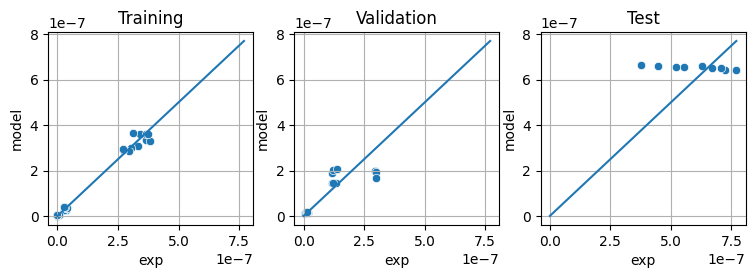

In [43]:
fig, ax = plt.subplots(1,3,figsize = (9, 2.5))

rates_WGS_max = rates_WGS[['exp', 'model']].max().max()

sns.scatterplot(data = rates_WGS.loc[rates_WGS.index.isin(idx_training)], x = 'exp', y = 'model', ax = ax[0])
ax[0].grid('both')
ax[0].plot((0, rates_WGS_max), (0, rates_WGS_max))
ax[0].set_title('Training')

sns.scatterplot(data = rates_WGS.loc[rates_WGS.index.isin(idx_validation)], x = 'exp', y = 'model', ax = ax[1])
ax[1].grid('both')
ax[1].plot((0, rates_WGS_max), (0, rates_WGS_max))
ax[1].set_title('Validation')

sns.scatterplot(data = rates_WGS.loc[rates_WGS.index.isin(idx_test)], x = 'exp', y = 'model', ax = ax[2])
ax[2].grid('both')
ax[2].plot((0, rates_WGS_max), (0, rates_WGS_max))
ax[2].set_title('Test')